# **Restaurant Layout Problem**
---
## **Summary**

This notebook present a comprehensive Mixed Integer Linear Programming (MILP) model for optimizing restaurant table layout. The model addresses the classic facility layout problem by:

- **Maximizing** table capacity and customer comfort
- **Ensuring** non-overlapping table placement
- **Optimizing** spatial utilization and personal space
- **Incorporating** flexible bay structures and table types

The model uses **advanced symmetry breaking techniques** including:
1. Sequential bay assignment
2. Vertical ordering within bays



# **1. Problem Definition**
---

## **The Restaurant Dilemma**

Imagine you are eating at a favorite restaurant. You want to go to the toilet, but have to wade through a maze of crowded tables. You feel uncomfortable because you have to pass by other people's tables that are too close. Your own chair is almost attached to the table behind you. **This is a classic problem in restaurant design.**

On the other hand, restaurant owners face a dilemma:
- **Too many tables** → Customers feel crowded, uncomfortable, will not return
- **Too few tables** → Lost potential revenue, wasted capacity
- **Bad layout** → Waiters have difficulty moving, slow service, bad experience


## **Problem Statement**

Given:
- **Room dimensions**: Width $W$, Height $H$
- **Table types**: Two types with dimensions $(w_{1}, h_{1})$ and $(w_{2}, h_{2})$
- **Comfort requirements**: Personal space $p$, minimum separation $d$
- **Operational constraints**: Bay structure for service

Find:
- Number of tables to place
- Position $(x_{m},y_{m})$ for each table $m$
- Table type and orientation (rotated or not)
- Bay assignments

Such that:
- No overlapping tables
- Personal space maintained
- Room boundaries respected

## **Parameters**

| Parameter | Symbol | Unit | Description |
|-----------|--------|------|-------------|
| Room width | $W$ | m | Available horizontal space |
| Room height | $H$ | m | Available vertical space |
| Table type 1 width | $w_1$ | m | Smaller table width |
| Table type 1 height | $h_1$ | m | Smaller table height |
| Table type 2 width | $w_2$ | m | Larger table width |
| Table type 2 height | $h_2$ | m | Larger table height |
| Personal space | $p$ | m | Minimum space around each table |
| Table separation | $d$ | m | Minimum gap between tables |
| Max tables | $N_{max}$ | - | Upper bound on table count |
| Number of bays | $B$ | - | Vertical sections for service |
| Profit from table type 1 | $P_{0}$ | IDR | Assume each chair give 50000 profit |
| Profit from table type 1 | $P_{1}$ | IDR | Assume each chair give 50000 profit |

In [1]:
# Create Parameters
W = 9
H = 6

# Description of the table type (width and height in meters)
tables = {
    "table_1" : {'width': 1.4, 'height': 0.78, 'profit': 100000},
    "table_2" : {'width': 0.78, 'height': 0.78, 'profit': 50000},
}

table_type = list(tables.keys())
wt = [tables[m]['width'] for m in table_type]
ht = [tables[m]['height'] for m in table_type]
table_profit = [tables[m]['profit'] for m in table_type]

p = 0.4 # Length of additional space for chair (in meters)
M = 100 # A big number
d = 0.5 # Minimal distance of each table (in meters)

## **Adaptive $N_{max}$ & $B$ Estimation**

### **Problem: Why Not Use Fixed Values?**

This approach is taken to make it easier to determine the number of tables and bays that can be realized in an area based on area geometry and comfort parameters.



### **Methodology: Grid-Based Capacity Estimation**

**Core Idea:**
> *Estimate how many tables can theoretically fit by dividing room into grid cells, where each cell must accommodate: table + personal space + separation gap*

**Two Dimensions:**
1. **Horizontal (Bays):** How many vertical strips (bays) can fit across width?
2. **Vertical (Rows):** How many tables can stack within each bay's height?



In [2]:
def estimate_N_max(W, H, wt, ht, p, d, buffer=0.10):
    """
    N_max estimation based on realistic grid packing.
    Take into account p (seat space), d (gap between tables), and bay structure.
    """
    # Max bay that can be active horizontally
    max_bays = 0
    for w_i, h_i in zip(wt, ht):
        bays_normal  = int(W / (w_i + 2*p + d))
        bays_rotated = int(W / (h_i + 2*p + d))
        max_bays = max(max_bays, bays_normal, bays_rotated)

    # Max tables per bay vertically
    max_rows = 0
    for w_i, h_i in zip(wt, ht):
        rows_normal  = int(H / (h_i + 2*p + d))
        rows_rotated = int(H / (w_i + 2*p + d))
        max_rows = max(max_rows, rows_normal, rows_rotated)

    # Compute N_max with a small buffer
    N_max = int(max_bays * max_rows * (1 + buffer))
    return N_max, max_bays


N_max, B = estimate_N_max(
    W=W, H=H, wt=wt, ht=ht, p=p, d=d, buffer=0.5
)

N_min = max(1, int(N_max * 0.3))

# **2. Mathematical Model**
---

## **Model Type**
- **Binary variables**: Table usage, bay assignment, table type, rotation, vertical ordering
- **Continuous variables**: Positions, table & bay dimensions, distances
- **Objective**: Multi-objective optimization (capacity + spacing + profit)
- **Constraints**: Non-overlap, boundaries, operational requirements

## **Decision Variables**

### **Binary Variables**

| Variable | Domain | Count | Description |
|----------|--------|-------|-------------|
| $u_{m}$ | $\{0,1\}$ | $N_{\max}$ | 1 if table $m$ is used |
| $z_{m,k}$ | $\{0,1\}$ | $N_{\max} \times B$ | 1 if table $m$ in bay $k$ |
| $t_{m}$ | $\{0,1\}$ | $N_{\max}$ | 1 if table $m$ is type 2, 0 if table $m$ is type 1 |
| $r_{m}$ | $\{0,1\}$ | $N_{\max}$ | 1 if table $m$ is rotated 90° |
| $q_{m}$ | $\{0,1\}$ | $N_{\max}$ | $q_{m}=r_{m}t_{m}$ |
| $l_{m,n}$ | $\{0,1\}$ | $N_{\max}^2$ | 1 if table $m$ above table $n$ |
| $\delta_{k}$ | $\{0,1\}$ | $B$ | 1 if bay $k$ is used |


### **Continuous Variables**

| Variable | Domain | Count | Description |
|----------|--------|-------|-------------|
| $x_m$ | $[0, W]$ | $N_{\max}$ | X-coordinate of table $m$ center |
| $y_m$ | $[0, H]$ | $N_{\max}$ | Y-coordinate of table $m$ center |
| $w_m$ | $\mathbb{R}^{+}$ | $N_{\max}$ | Width of table $m$ |
| $h_m$ | $\mathbb{R}^{+}$ | $N_{\max}$ | Height of table $m$ |
| $D_{m,n}^{x}$ | $\mathbb{R}^{+}$ | $\frac{N_{\max}(N_{\max}-1)}{2}$ | Horizontal distance between $m$, $n$ |
| $D_{m,n}^{y}$ | $\mathbb{R}^{+}$ | $\frac{N_{\max}(N_{\max}-1)}{2}$ | Vertical distance between $m$, $n$ |
| $\omega_k$ | $[0, W]$ | $B$ | Width of bay $k$ |
| $\beta_{m,k}$ | $\mathbb{R}^{+}$ | $N_{\max} \times B$ | Required width if $m$ in $k$ |

In [3]:
# Import Library
!pip install gurobipy
import gurobipy as gp
from gurobipy import GRB

In [4]:
# Define the model
model = gp.Model("Table Mix Problem")


# Define Variables
# Continous Variables
x = model.addVars(range(N_max), name="x", vtype=GRB.CONTINUOUS, lb=0)
y = model.addVars(range(N_max), name="y", vtype=GRB.CONTINUOUS, lb=0)
w = model.addVars(range(N_max), name="w", vtype=GRB.CONTINUOUS, lb=0)
h = model.addVars(range(N_max), name="h", vtype=GRB.CONTINUOUS, lb=0)
Dx = model.addVars([(m,n) for m in range(N_max) for n in range(m+1, N_max)], name="Dx", vtype=GRB.CONTINUOUS, lb=0)
Dy = model.addVars([(m,n) for m in range(N_max) for n in range(m+1, N_max)], name="Dy", vtype=GRB.CONTINUOUS, lb=0)
omega = model.addVars(range(B), name="omega", vtype=GRB.CONTINUOUS, lb=0)
beta = model.addVars(range(N_max), range(B), name="beta", vtype=GRB.CONTINUOUS, lb=0)

# Binary Variables
z = model.addVars(range(N_max), range(B), name="z", vtype=GRB.BINARY)
l = model.addVars(range(N_max), range(N_max), name="l", vtype=GRB.BINARY)
delta = model.addVars(range(B), name="delta", vtype=GRB.BINARY)
r = model.addVars(range(N_max), name="r", vtype=GRB.BINARY)
t = model.addVars(range(N_max), name="t", vtype=GRB.BINARY)
q = model.addVars(range(N_max), name="q", vtype=GRB.BINARY)
u = model.addVars(range(N_max), name="u", vtype=GRB.BINARY)

model.update()

Restricted license - for non-production use only - expires 2027-11-29


## **Objective Function**

### **Purpose**
- **Maximize** number of tables
- **Maximize** free space in area using **minimize** the distance from each table
- **Maximze** profit

### **Normalize function**

Because the three functions have different units, normalization is carried out for each objective function.
1. Maximize number of tables
  $$
    \begin{align}
      & T = \sum_{m=1}^{N_{max}} u_{m} \\
      & T_{norm} = \frac{T - N_{min}}{N_{max} - N_{min}}
    \end{align}
  $$

2. Maximize free space
  $$
    \begin{align}
      & S = \sum_{m < n} \left( D_{mn}^{x} + D_{mn}^{y} \right)\\
      & S_{norm} = \frac{S}{N_{max}(N_{max}-1)/2(W+H)}
    \end{align}
  $$

3. Maximize profit
  $$
    \begin{align}
      & Q = \sum_{m=1}^{N}\left(P_{0}(1-t_{m}) + P_{1}t_{m} \right)\\
      & Q_{norm} = \frac{Q - N_{min}P_{1}}{N_{max}P_{0} - N_{min}P_{1}}
    \end{align}
  $$

### **Final objective function**

$$
  \begin{align}
    & \text{max } Z=\alpha T_{norm} + \gamma S_{norm} + (1-\alpha-\gamma)Q_{norm}
  \end{align}
$$

with $\alpha, \gamma \in [0,1]$ and $\alpha+\gamma \leq 1$.

In [5]:
# Objective Function

# Parameters for multiobjective function
alpha = 0.4
gamma = 0.3

# Objective 1 : Number of tables function
num_tables_normalized = (gp.quicksum(u[m] for m in range(N_max)) - N_min) / (N_max - N_min)

# Objective 2 : Free space
total_spacing = gp.quicksum(Dx[m,n] + Dy[m,n] for m in range(N_max) for n in range(m+1, N_max))
max_possible_spacing = N_max*(N_max - 1) / 2*(W + H)
spacing_normalized = total_spacing / max_possible_spacing

# Objective 3 : Total profit
total_profit = gp.quicksum(table_profit[0]*(1 - t[m]) + table_profit[1]*t[m] for m in range(N_max))
total_profit_normalized = (total_profit - N_min*table_profit[1]) / (N_max*table_profit[0] - N_min*table_profit[1])

# The function
obj = alpha*num_tables_normalized
obj += gamma*spacing_normalized
obj += (1-alpha-gamma)*total_profit_normalized

model.setObjective(obj, sense=GRB.MAXIMIZE)
model.update()

## **Constraints**
---

### **Constraint 1: Usage-Bay Assignment Link**

Table is used if and only if it's assigned to exactly one bay.

$$
  \begin{align}
    &\sum_{k=1}^{B} z_{mk} = u_{m} &&\forall m
  \end{align}
$$

In [6]:
# Constraint 1: Usage-Bay Assignment Link

for m in range(N_max):
  model.addConstr(gp.quicksum(z[m,k] for k in range(B)) == u[m])

model.update()

### **Constraint 2: Bay Usage Activation**

Bay $k$ is marked as used ($\delta_{k}=1$) if and only if at least one table is assigned to it.

$$
  \begin{align}
    &\delta_{k} \geq z_{mk} &&\forall m,k
  \end{align}
$$

In [7]:
# Constraint 2: Bay Usage Activation

for k in range(B):
  for m in range(N_max):
    model.addConstr(delta[k] >= z[m,k])

model.update()

### **Constraint 3: Symmetry Breaking - Table Usage Ordering**

Break symmetry by enforcing lexicographic ordering of table usage.

$$
  \begin{align}
    & y_{m}-0.5(h_{m}+p) \geq y_{n}+0.5(h_{n}+p)+d-H(1-l_{mn})-M(2-u_{m}-u_{n}) &&\forall m,n, n \neq m \\
		& l_{m+1,m} \geq z_{mk} + z_{m+1,k} - 1 &&\forall k \in B, m \in \{1, \ldots, N_{max}-1\} \\
		& l_{m,m+1} \leq 2 - z_{mk} - z_{m+1,k} &&\forall k \in B, m \in \{1, \ldots, N_{max}-1\} \\
		& u_{m} \geq u_{m+1} &&\forall m \in \{1, \ldots, N_{max}-1\}
  \end{align}
$$

In [8]:
# Constraint 3: Symmetry Breaking - Table Usage Ordering

for m in range(N_max):
  for n in range(N_max):
    if n != m:
      model.addConstr(y[m] - 0.5*(h[m] + p) >= y[n] + 0.5*(h[n] + p) + d - H*(1-l[m,n]) - M*(2-u[m]-u[n]))

for k in range(B):
  for m in range(N_max-1):
    model.addConstr(l[m+1,m] >= z[m,k] + z[m+1,k] - 1)
    model.addConstr(l[m,m+1] <= 2 - z[m,k] - z[m+1,k])

for m in range(N_max-1):
  model.addConstr(u[m] >= u[m+1])

model.update()

### **Constraint 4: Symmetry Breaking - Bay Usage Ordering**

Break symmetry by enforcing lexicographic ordering of bay usage.

$$
	\begin{align}
		& \delta_{k} \geq \delta_{k+1} &&\forall k \in \{1, \ldots, B-1\}
	\end{align}
$$

In [9]:
# Constraint 4: Symmetry Breaking - Bay Usage Ordering
for k in range(B-1):
  model.addConstr(delta[k] >= delta[k+1])

model.update()

### **Constraint 5: Table Width Assignment**

Adjust table dimensions with rotation and type decisions.

$$
	\begin{align}
		 &w_{m} = w_{1}+(w_{2}-w_{1})t_{m}+(h_{1}-w_{1})r_{m}+(w_{1}-w_{2}+h_{2}-h_{1})q_{m}, &&\forall m \\
		 &h_{m} = h_{1}+(h_{2}-h_{1})t_{m}+(w_{1}-h_{1})r_{m}+(h_{1}-h_{2}+w_{2}-w_{1})q_{m}, &&\forall m
	\end{align}
$$

In [10]:
# Constraint 5: Table Width Assignment

for m in range(N_max):
  model.addConstr(w[m] == wt[0] + (wt[1]-wt[0])*t[m] + (ht[0]-wt[0])*r[m] + (wt[0]-wt[1]+ht[1]-ht[0])*q[m])
  model.addConstr(h[m] == ht[0] + (ht[1]-ht[0])*t[m] + (wt[0]-ht[0])*r[m] + (ht[0]-ht[1]+wt[1]-wt[0])*q[m])

model.update()

### **Constraint 6: Distance Calculation**

Calculate Manhattan distance:
$D_{mn}^{x} = |x_{m}-x_{n}|, D_{mn}^{y} = |y_{m} - y_{n}|$

$$
  \begin{align}
		  &D_{mn}^{x} \geq x_{m}-x_{n} - M(2-u_{m}-u_{n}), &&&\forall m, \forall n \in \{m+1, N_{max}\} \\
		  &D_{mn}^{x} \geq x_{n}-x_{m} - M(2-u_{m}-u_{n}), &&&\forall m, \forall n \in \{m+1, N_{max}\}  \\
		  &D_{mn}^{y} \geq y_{m}-y_{n} - M(2-u_{m}-u_{n}), &&&\forall m, \forall n \in \{m+1, N_{max}\}  \\
		  &D_{mn}^{y} \geq y_{n}-y_{m} - M(2-u_{m}-u_{n}), &&&\forall m, \forall n \in \{m+1, N_{max}\}
	\end{align}
$$

In [11]:
# Constraint 6: Distance Calculation

for m in range(N_max):
  for n in range(m+1, N_max):
    model.addConstr(Dx[m,n] >= x[m] - x[n] - M*(2 - u[m] - u[n]))
    model.addConstr(Dx[m,n] >= x[n] - x[m] - M*(2 - u[m] - u[n]))
    model.addConstr(Dy[m,n] >= y[m] - y[n] - M*(2 - u[m] - u[n]))
    model.addConstr(Dy[m,n] >= y[n] - y[m] - M*(2 - u[m] - u[n]))

model.update()

### **Constraint 7: Distance Bounds**

Force $D_{mn}^{x} = D_{mn}^{y} = 0$ if either table is unused

$$
  \begin{align}
		 & D_{mn}^{x} \leq \frac{1}{2}(W+H)(u_{m}+u_{n}) &&\forall m, \forall n \in \{m+1, N_{max}\} \\
		 & D_{mn}^{y} \leq \frac{1}{2}(W+H)(u_{m}+u_{n}) &&\forall m, \forall n \in \{m+1, N_{max}\}
	\end{align}
$$

In [12]:
# Constraint 7: Distance Bounds

for m in range(N_max):
  for n in range(m+1, N_max):
    model.addConstr(Dx[m,n] <= 0.5*(W + H)*(u[m] + u[n]))
    model.addConstr(Dy[m,n] <= 0.5*(W + H)*(u[m] + u[n]))

model.update()

### **Constraint 8: Auxiliary Variable $q_{m}$**

Define $q_{m} = t_{m} \land r_{m}$

$$
  \begin{align}
		 & q_{m} \leq r_{m} &&\forall m \\
		 & q_{m} \leq t_{m} &&\forall m \\
		 & q_{m} \geq r_{m}+t_{m}-1 &&\forall m
	\end{align}
$$

In [13]:
# Constraint 8: Auxiliary Variable q[m]

for m in range(N_max):
  model.addConstr(q[m] <= t[m])
  model.addConstr(q[m] <= r[m])
  model.addConstr(q[m] >= r[m] + t[m] - 1)

model.update()

### **Constraint 9: Type/Rotation Only If Used**

If table not used, force type and rotation to 0

$$
  \begin{align}
    & t_{m} \leq u_{m} &&\forall m \\
		& r_{m} \leq u_{m} &&\forall m
  \end{align}
$$

In [14]:
# Constraint 9: Type/Rotation Only If Used

for m in range(N_max):
  model.addConstr(t[m] <= u[m])
  model.addConstr(r[m] <= u[m])

model.update()

### **Constraint 10: Required Width in Bay**

Variable $\beta_{mk}$ captures required width if table $m$ is in bay $k$.

$$
  \begin{align}
    & \beta_{mk} \leq w_{m}+2p+d &&\forall m,k \\
		& \beta_{mk} \geq w_{m}+2p+d-M(1-z_{mk}) &&\forall m,k \\
		& \beta_{mk} \leq \omega_{k} &&\forall m,k
  \end{align}
$$

In [15]:
# Constraint 10: Required Width in Bay

for k in range(B):
  for m in range(N_max):
    model.addConstr(beta[m,k] <= w[m] + 2*p + d)
    model.addConstr(beta[m,k] >= w[m] + 2*p + d - M*(1 - z[m,k]))
    model.addConstr(beta[m,k] <= omega[k])

model.update()

### **Constraint 11: Horizontal Centering**

Center table horizontally within it's assigned bay

$$
	\begin{align}
		  &x_{m} \geq \sum_{j=1}^{k+1}\omega_{j} - 0.5\omega_{k}-W(1-z_{mk}) &&\forall m,k \\
		  &x_{m} \leq \sum_{j=1}^{k+1}\omega_{j} - 0.5\omega_{k}+W(1-z_{mk}) &&\forall m,k
	\end{align}
$$

In [16]:
# Constraint 11: Horizontal Centering

for k in range(B):
  for m in range(N_max):
    model.addConstr(x[m] >= gp.quicksum(omega[j] for j in range(k+1)) - 0.5*omega[k] - W*(1-z[m,k]))
    model.addConstr(x[m] <= gp.quicksum(omega[j] for j in range(k+1)) - 0.5*omega[k] + W*(1-z[m,k]))

model.update()

### **Constraint 12: Bay Width Sum**

Total Bay widths cannot exceed room width

$$
  \begin{align}
    & \sum_{k=1}^{B} \omega_{k} \leq W
  \end{align}
$$

In [17]:
# Constraint 12: Bay Width Sum

model.addConstr((gp.quicksum(omega[k] for k in range(B)) <= W))
model.update()

### **Constraint 13: Vertical Room Boundaries**

Table (with personal space) must fit within room height $[0,H]$

$$
  \begin{align}
    &y_{m} \leq H-(0.5h_{m}+p)+M(1-u_{m}) &&\forall m \\
		&y_{m} \geq 0.5h_{m}+p-M(1-u_{m}) &&\forall m
  \end{align}
$$

In [18]:
# Constraint 13: Vertiacl Room Baoundaries

for m in range(N_max):
  model.addConstr(y[m] <= H - (0.5*h[m] + p) + M*(1-u[m]))
  model.addConstr(y[m] >= 0.5*h[m] + p - M*(1-u[m]))

model.update()

### **Constraint 14: Sequential Bay Assignment**

Table $m$ can be in bay $k$ only if table $m-1$ is in bay $\leq k$.

$$
  \begin{align}
    & z_{mk} \leq \sum_{j=1}^{k} z_{m-1,j} &&\forall m \in \{2, \ldots, N_{max}\}, \forall k
  \end{align}
$$

In [19]:
# Constraint 14: Sequential Bay Assignment

for m in range(1, N_max):
  for k in range(B):
    model.addConstr(z[m,k] <= gp.quicksum(z[m-1,j] for j in range(k+1)))

model.update()

# **3. Solve Model**
---


In [20]:
# Solve the model

model.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1083 rows, 476 columns and 4302 nonzeros (Max)
Model fingerprint: 0x645b9ded
Model has 156 linear objective coefficients and an objective constant of -1.6666666666666666e-01
Variable types: 232 continuous, 244 integer (244 binary)
Coefficient statistics:
  Matrix range     [5e-01, 1e+02]
  Objective range  [3e-04, 4e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e-01, 2e+02]

Found heuristic solution: objective 0.1666667
Presolve removed 641 rows and 346 columns
Presolve time: 0.05s
Presolved: 442 rows, 130 columns, 1930 nonzeros
Variable types: 28 continuous, 102 integer (72 binary)

Root relaxation: objective 1.300000e+00, 111 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective

# **4. Visualization**

In [21]:
import pandas as pd

solution_data = []

if model.Status == GRB.OPTIMAL or model.SolCount > 0:
    for m in range(N_max):
        if u[m].X > 0.5:  # Check if table m is used
            table_type_idx = 0
            table_orientation = "normal"

            if r[m].X > 0.5: # If r[m] is 1, table is rotated (width becomes height, height becomes width)
                table_orientation = "rotated"

            if t[m].X > 0.5: # If t[m] is 1, it's table_2 (index 1)
                table_type_idx = 1

            # Determine the original table type name
            original_table_name = table_type[table_type_idx]

            solution_data.append({
                'Table Index': m,
                'Type': original_table_name,
                'Orientation': table_orientation,
                'X Position': x[m].X,
                'Y Position': y[m].X,
                'Width': w[m].X,
                'Height': h[m].X
            })

    solution = pd.DataFrame(solution_data)
    print(f"Objective Value: {model.ObjVal:.4f}")
    print("Number of tables placed:", len(solution))
    print(solution)
else:
    print("No optimal or feasible solution found.")
    print("Model status:", model.Status)

Objective Value: 1.2143
Number of tables placed: 12
    Table Index     Type Orientation  X Position  Y Position  Width  Height
0             0  table_1     rotated        1.35        1.10   0.78    1.40
1             1  table_1      normal        1.35        3.09   1.40    0.78
2             2  table_1      normal        1.35        4.77   1.40    0.78
3             3  table_2      normal        3.74        0.89   0.78    0.78
4             4  table_1     rotated        3.74        2.88   0.78    1.40
5             5  table_2      normal        3.74        4.87   0.78    0.78
6             6  table_2      normal        5.82        0.79   0.78    0.78
7             7  table_1     rotated        5.82        2.78   0.78    1.40
8             8  table_2      normal        5.82        4.77   0.78    0.78
9             9  table_1     rotated        7.90        1.20   0.78    1.40
10           10  table_2      normal        7.90        3.19   0.78    0.78
11           11  table_2      normal

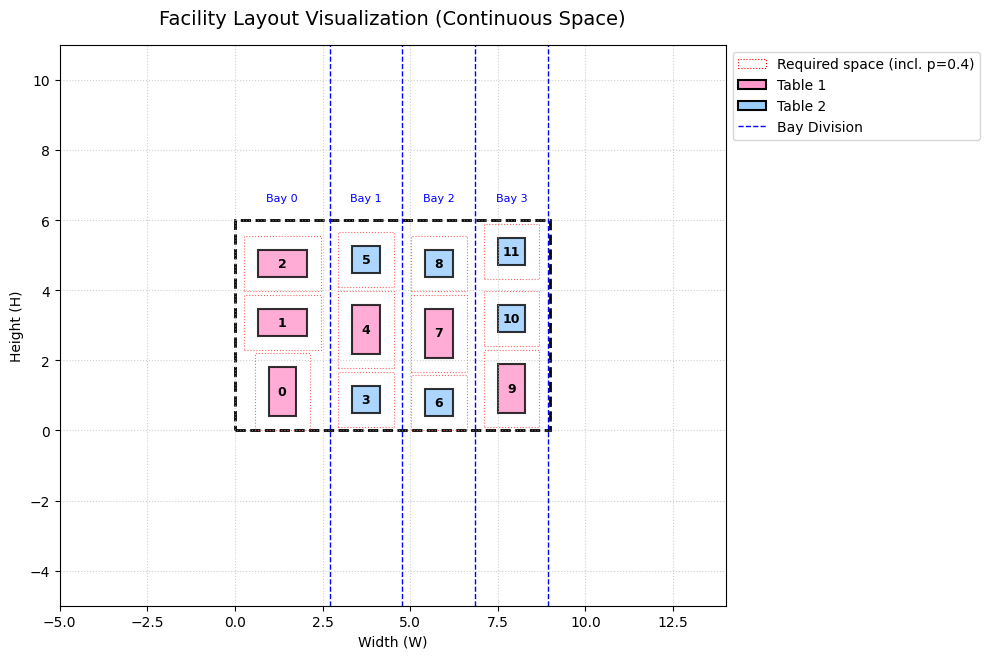

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Visualize solution

fig, ax = plt.subplots(figsize=(10,10))

# Draw the overall factory boundary
batas_pabrik = patches.Rectangle(
    (0,0), W, H,
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
ax.add_patch(batas_pabrik)

# Color options for each facility
colors = {'table_1': '#ff99cc', 'table_2': '#99ccff'}

# Looping to draw each facility
for index, row in solution.iterrows():
    table_index = row['Table Index']
    table_type_name = row['Type']
    table_x = row['X Position']
    table_y = row['Y Position']
    table_w = row['Width']
    table_h = row['Height']

    # CONVERSION: From Center Point coordinates (x,y) to Bottom-Left (bottom-left)
    bottom_left_x = table_x - (table_w / 2)
    bottom_left_y = table_y - (table_h / 2)

    # Create a facility box object (the table itself)
    rect = patches.Rectangle(
        (bottom_left_x, bottom_left_y),
        table_w,
        table_h,
        linewidth=1.5,
        edgecolor='black',
        facecolor=colors[table_type_name],
        alpha=0.8
    )
    ax.add_patch(rect)

    # Added Text/Label in the middle of the facility box
    label_teks = f"{table_index}"
    ax.text(
        table_x, table_y,
        label_teks,
        ha='center', va='center',         # Center alignment
        fontsize=9, weight='bold'
    )

    # --- Add visualization for 'p' (additional space) ---
    # Draw a larger dashed rectangle representing the required space for the table including 'p'
    p_rect_patch = patches.Rectangle(
        (bottom_left_x - p, bottom_left_y - p), # Shift by -p to expand symmetrically
        table_w + 2 * p,                        # Expand width by 2*p
        table_h + 2 * p,                        # Expand height by 2*p
        linewidth=0.8,
        edgecolor='red',
        facecolor='none',
        linestyle=':',
        alpha=0.6
    )
    ax.add_patch(p_rect_patch)


# --- Add visualization for bays ---
bay_left_boundary = 0
bay_line_drawn_for_legend = False # Flag to add label only once for the legend
bay_labels = [] # To store bay label text and position for later drawing

for k in range(B):
    bay_width = omega[k].X # Access optimal value of Gurobi variable
    if bay_width > 1e-6: # Only process bays with significant positive width
        bay_right_boundary = bay_left_boundary + bay_width

        # Draw a vertical line for the right boundary of the current bay
        # Only draw if it's not effectively the overall right boundary of the plant
        if abs(bay_right_boundary - W) > 1e-6:
            ax.axvline(x=bay_right_boundary, color='blue', linestyle='--', linewidth=1,
                       label='Bay Division' if not bay_line_drawn_for_legend else "")
            bay_line_drawn_for_legend = True

        # Store label info
        bay_labels.append({
            'x': bay_left_boundary + bay_width / 2,
            'text': f"Bay {k}"
        })

        bay_left_boundary = bay_right_boundary

# Add bay labels to the plot after all bay lines are potentially drawn
for label_info in bay_labels:
    ax.text(
        label_info['x'], H + 0.5,
        label_info['text'],
        ha='center', va='bottom',
        fontsize=8, color='blue'
    )


ax.set_xlim(-5, W + 5)                # Leave some margin space on the X axis
ax.set_ylim(-5, H + 5)                # Leave some margin space on the Y axis
ax.set_aspect('equal')                # IMPORTANT: Maintain the length and width ratio without distortion
ax.set_title("Facility Layout Visualization (Continuous Space)", fontsize=14, pad=15)
ax.set_xlabel("Width (W)")
ax.set_ylabel("Height (H)")
ax.grid(True, linestyle=':', alpha=0.6)

# Create custom legend handles
handles = []
labels = []

# Add a dummy patch for 'p' space to the legend
p_legend_patch = patches.Rectangle((0,0), 1, 1, fill=False, edgecolor='red', linestyle=':', linewidth=0.8)
handles.append(p_legend_patch)
labels.append(f"Required space (incl. p={p})")

# Add dummy patches for table types to the legend
for table_name, color_val in colors.items():
    table_legend_patch = patches.Rectangle((0,0), 1, 1, facecolor=color_val, edgecolor='black', linewidth=1.5)
    handles.append(table_legend_patch)
    labels.append(table_name.replace('_', ' ').title())

# Add a dummy line for Bay Divisions to the legend
bay_legend_line = plt.Line2D([0], [0], color='blue', linestyle='--', linewidth=1)
handles.append(bay_legend_line)
labels.append("Bay Division")

# Add legend to the plot
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()